<a href="https://colab.research.google.com/github/Aastha210/BERT_Sentiment_Analysis/blob/main/BERT_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
!pip install -q transformers datasets accelerate scikit-learn

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from tensorflow.keras.datasets import imdb

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [44]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=10000
)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 25000
Testing samples: 25000


In [45]:
word_index = imdb.get_word_index()

# Reverse the dictionary
reverse_word_index = {
    value: key
    for key, value in word_index.items()
}

# Special tokens
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

In [46]:
def decode_review(encoded_review):
    return " ".join(
        reverse_word_index.get(i - 3, "<UNK>")
        for i in encoded_review
    )

train_texts = [
    decode_review(review)
    for review in x_train
]

test_texts = [
    decode_review(review)
    for review in x_test
]

print("First review:")
print(train_texts[0])

print("\nFirst label:")
print(y_train[0])

First review:
<UNK> this film was just brilliant casting location scenery story direction everyone's really suited <START> part they played <UNK> you could just imagine being there robert <UNK> is an amazing actor <UNK> now <START> same being director <UNK> father came from <START> same scottish island as myself so i loved <START> fact there was <UNUSED> real connection with this film <START> witty remarks throughout <START> film were great it was just brilliant so much that i bought <START> film as soon as it was released for <UNK> <UNK> would recommend it to everyone to watch <UNK> <START> fly fishing was amazing really cried at <START> end it was so sad <UNK> you know what they say if you cry at <UNUSED> film it must have been good <UNK> this definitely was also <UNK> to <START> two little boy's that played <START> <UNK> of norman <UNK> paul they were just brilliant children are often left out of <START> <UNK> list i think because <START> stars that play them all grown up are such <

In [47]:
train_size = 5000
test_size = 1000

train_texts = train_texts[:train_size]
train_labels = y_train[:train_size]

test_texts = test_texts[:test_size]
test_labels = y_test[:test_size]

print("Training reviews:", len(train_texts))
print("Testing reviews:", len(test_texts))

Training reviews: 5000
Testing reviews: 1000


In [48]:
train_df = pd.DataFrame({
    "text": train_texts,
    "label": train_labels
})

test_df = pd.DataFrame({
    "text": test_texts,
    "label": test_labels
})

print(train_df.head())

                                                text  label
0  <UNK> this film was just brilliant casting loc...      1
1  <UNK> big hair big boobs bad music <UNK> <UNUS...      0
2  <UNK> this has to be one of <START> worst film...      0
3  <UNK> <START> <UNK> <UNK> at storytelling <STA...      1
4  <UNK> worst mistake of my life br br i picked ...      0


In [49]:
model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("BERT tokenizer loaded successfully!")

BERT tokenizer loaded successfully!


In [50]:
train_dataset = Dataset.from_pandas(
    train_df
)

test_dataset = Dataset.from_pandas(
    test_df
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})


In [51]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed!")

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenization completed!


In [52]:
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
test_dataset.set_format("torch")

print(train_dataset)

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})


In [53]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

print("BERT model loaded successfully!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded successfully!


In [54]:
def compute_metrics(eval_pred):

    predictions = np.argmax(
        eval_pred.predictions,
        axis=1
    )

    labels = eval_pred.label_ids

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [58]:
training_args = TrainingArguments(
    output_dir="./bert_sentiment_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=1,

    weight_decay=0.01,

    logging_steps=50,

    load_best_model_at_end=True,

    report_to="none"
)

In [59]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

Trainer created successfully!


In [60]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.383955,0.382265,0.827000,0.763573,0.919831,0.834450


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=313, training_loss=0.3650617721362617, metrics={'train_runtime': 146.4386, 'train_samples_per_second': 34.144, 'train_steps_per_second': 2.137, 'total_flos': 328888819200000.0, 'train_loss': 0.3650617721362617, 'epoch': 1.0})

In [61]:
results = trainer.evaluate()

print("\nEvaluation Results:")

for key, value in results.items():

    if isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.383955,0.382265,1,0.827000,0.763573,0.919831,0.834450



Evaluation Results:
eval_loss: 0.3823
eval_accuracy: 0.8270
eval_precision: 0.7636
eval_recall: 0.9198
eval_f1: 0.8344


In [62]:
prediction_output = trainer.predict(
    test_dataset
)

predicted_labels = np.argmax(
    prediction_output.predictions,
    axis=1
)

actual_labels = prediction_output.label_ids

print("Predicted labels:")
print(predicted_labels[:20])

print("\nActual labels:")
print(actual_labels[:20])

Predicted labels:
[0 1 1 0 1 0 0 1 1 0 1 0 0 1 1 0 1 1 0 0]

Actual labels:
[0 1 1 0 1 1 1 0 0 1 1 0 0 0 1 0 1 0 0 0]


In [63]:
print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.91      0.74      0.82       526
    Positive       0.76      0.92      0.83       474

    accuracy                           0.83      1000
   macro avg       0.84      0.83      0.83      1000
weighted avg       0.84      0.83      0.83      1000



In [64]:
cm = confusion_matrix(
    actual_labels,
    predicted_labels
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[391 135]
 [ 38 436]]


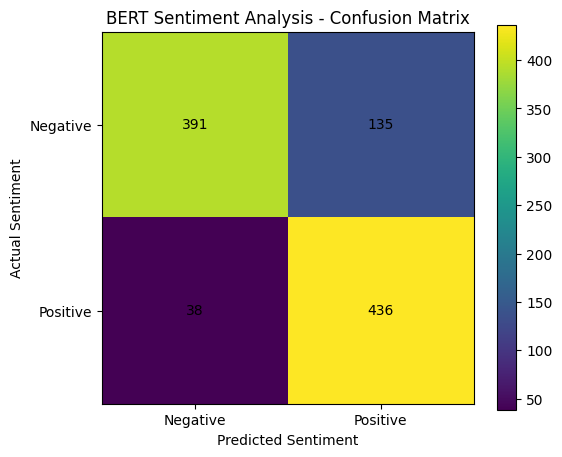

In [65]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    "BERT Sentiment Analysis - Confusion Matrix"
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.xticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.yticks(
    [0, 1],
    ["Negative", "Positive"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

In [66]:
def predict_sentiment(text):

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model.to(device)
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():

        outputs = model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )

    prediction = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = probabilities[
        0, prediction
    ].item()

    if prediction == 1:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    return sentiment, confidence

In [67]:
reviews = [
    "This movie was absolutely fantastic and I loved every minute of it.",
    "The movie was boring and a complete waste of time.",
    "The acting was excellent and the story was very interesting.",
    "I did not enjoy this movie at all.",
    "One of the best movies I have ever watched."
]

for review in reviews:

    sentiment, confidence = predict_sentiment(review)

    print("Review:", review)
    print("Sentiment:", sentiment)
    print(
        "Confidence:",
        round(confidence * 100, 2),
        "%"
    )
    print("-" * 70)

Review: This movie was absolutely fantastic and I loved every minute of it.
Sentiment: Positive
Confidence: 95.11 %
----------------------------------------------------------------------
Review: The movie was boring and a complete waste of time.
Sentiment: Negative
Confidence: 97.42 %
----------------------------------------------------------------------
Review: The acting was excellent and the story was very interesting.
Sentiment: Positive
Confidence: 93.64 %
----------------------------------------------------------------------
Review: I did not enjoy this movie at all.
Sentiment: Negative
Confidence: 88.44 %
----------------------------------------------------------------------
Review: One of the best movies I have ever watched.
Sentiment: Positive
Confidence: 91.72 %
----------------------------------------------------------------------


In [68]:
my_review = "The movie was really enjoyable and the acting was amazing."

sentiment, confidence = predict_sentiment(
    my_review
)

print("Review:", my_review)
print("Predicted Sentiment:", sentiment)
print(
    "Confidence:",
    round(confidence * 100, 2),
    "%"
)

Review: The movie was really enjoyable and the acting was amazing.
Predicted Sentiment: Positive
Confidence: 95.5 %


In [70]:
my_review = "The movie was really bad and the acting was worst."

sentiment, confidence = predict_sentiment(
    my_review
)

print("Review:", my_review)
print("Predicted Sentiment:", sentiment)
print(
    "Confidence:",
    round(confidence * 100, 2),
    "%"
)

Review: The movie was really bad and the acting was worst.
Predicted Sentiment: Negative
Confidence: 98.02 %
